# Sentiment & Emotion Analysis Pipeline

Applies two pre-trained HuggingFace models to the top-5 most helpful reviews per product:
- **Sentiment:** `cardiffnlp/twitter-roberta-base-sentiment-latest` (positive / neutral / negative)
- **Emotion:** `j-hartmann/emotion-english-distilroberta-base` (joy, anger, sadness, fear, disgust, surprise, neutral)

Models are used for inference only — no training performed.

# Step 1 — Dependencies + Notebook Skeleton
## Imports

In [1]:
import pandas as pd
import numpy as np
import torch
from transformers import pipeline
from pathlib import Path

c:\Users\user\Documents\Projects\AIDL GP\WM9B7-AIDL-AmazonReview\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Device setup

In [2]:
device = 0 if torch.cuda.is_available() else -1
device_name = "GPU (cuda:0)" if device == 0 else "CPU"
print(f"Running inference on: {device_name}")

Running inference on: GPU (cuda:0)


## Data availability check

In [3]:
DATA_PATH = Path("../data/processed/amazon_reviews_s10.parquet")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"{DATA_PATH} not found. Run:\n  git lfs install\n  git lfs pull"
    )

file_size_mb = DATA_PATH.stat().st_size / (1024 ** 2)
if file_size_mb < 1:
    raise RuntimeError(
        f"{DATA_PATH} is only {file_size_mb:.1f} MB — likely a Git LFS pointer, not the actual file.\n"
        "Run:\n  git lfs install\n  git lfs pull"
    )

print(f"Data file OK: {file_size_mb:.0f} MB")

Data file OK: 318 MB


## Load data

In [4]:
df = pd.read_parquet(DATA_PATH)
print(f"Loaded {len(df):,} reviews | {df['parent_asin'].nunique():,} products")
df.head(3)

Loaded 942,176 reviews | 294,158 products


,rating,images,parent_asin,timestamp,helpful_vote,review_text,review_length,is_verified,image_count,has_image,days_since_first_review,product_popularity
0,5,[],B0051VVOB2,2012-01-28 13:35:06,3,Kindle Fire Initially I had trouble using the ...,1832,1,0,False,5548,13072
1,5,[],B010BWYDYA,2008-11-26 16:11:05,2,I'm amazed This is my first experience with an...,445,1,0,False,4390,16910
2,5,[],B0051VVOB2,2011-12-25 19:15:13,4,Fabulous!! I absolutely Love the Kindle Fire. ...,701,1,0,False,5515,13072


## Filter: top-5 per product

In [5]:
df_top5 = (
    df
    .sort_values(["helpful_vote", "review_length"], ascending=[False, False])
    .groupby("parent_asin", as_index=False)
    .head(5)
    .reset_index(drop=True)
)
print(f"After filtering: {len(df_top5):,} reviews | {df_top5['parent_asin'].nunique():,} products")

After filtering: 599,361 reviews | 294,158 products


## Load sentiment model

In [6]:
SENTIMENT_MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"

sentiment_pipe = pipeline(
    "sentiment-analysis",
    model=SENTIMENT_MODEL,
    device=device,
    top_k=None,  # return all 3 class scores
)
print(f"Sentiment model ready: {SENTIMENT_MODEL}")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 14357.69it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sentiment model ready: cardiffnlp/twitter-roberta-base-sentiment-latest


## Load emotion model

In [7]:
EMOTION_MODEL = "j-hartmann/emotion-english-distilroberta-base"

emotion_pipe = pipeline(
    "text-classification",
    model=EMOTION_MODEL,
    device=device,
    top_k=None,  # return all 7 class scores
)
print(f"Emotion model ready: {EMOTION_MODEL}")

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 17424.41it/s]
RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Emotion model ready: j-hartmann/emotion-english-distilroberta-base


## Smoke test on 100 rows

In [8]:
SAMPLE_SIZE = 100
sample_texts = df_top5["review_text"].head(SAMPLE_SIZE).tolist()

sentiment_results = sentiment_pipe(sample_texts, truncation=True, max_length=512, batch_size=16)
emotion_results   = emotion_pipe(sample_texts,   truncation=True, max_length=512, batch_size=16)

print(f"Inference complete on {SAMPLE_SIZE} reviews.")
print("\nSample sentiment output (first review):")
print(sentiment_results[0])
print("\nSample emotion output (first review):")
print(emotion_results[0])

Inference complete on 100 reviews.

Sample sentiment output (first review):
[{'label': 'positive', 'score': 0.8149162530899048}, {'label': 'neutral', 'score': 0.16339026391506195}, {'label': 'negative', 'score': 0.021693434566259384}]

Sample emotion output (first review):
[{'label': 'neutral', 'score': 0.7835482954978943}, {'label': 'surprise', 'score': 0.12676359713077545}, {'label': 'joy', 'score': 0.0355803407728672}, {'label': 'sadness', 'score': 0.023907575756311417}, {'label': 'anger', 'score': 0.014705050736665726}, {'label': 'disgust', 'score': 0.012085678987205029}, {'label': 'fear', 'score': 0.003409421071410179}]


In [9]:
print("CUDA available:", torch.cuda.is_available())
print("Device used:", device)

CUDA available: True
Device used: 0


## Inference configuration

In [10]:
# Set to an integer (e.g. 10_000) to limit rows for CPU testing.
# Set to None to run on the full filtered dataset (recommended on GPU).
MAX_REVIEWS = 10_000

BATCH_SIZE = 32  # increase to 64 or 128 on GPU
OUTPUT_PATH = Path("../data/processed/sentiment_emotion_results.parquet")

df_inference = df_top5.head(MAX_REVIEWS) if MAX_REVIEWS else df_top5
print(f"Running inference on {len(df_inference):,} reviews")

Running inference on 10,000 reviews


## Batched inference helper

In [11]:
from tqdm.auto import tqdm

def run_batched(pipe, texts, batch_size=32):
    """Run a HuggingFace pipeline in batches with a progress bar."""
    results = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i : i + batch_size]
        outputs = pipe(batch, truncation=True, max_length=512)
        results.extend(outputs)
    return results

def parse_scores(results):
    """Convert [{'label': ..., 'score': ...}, ...] to {label: score} dicts."""
    return [{item["label"]: round(item["score"], 4) for item in r} for r in results]

## Run sentiment inference

In [12]:
print("Running sentiment inference...")
texts = df_inference["review_text"].tolist()
sentiment_raw = run_batched(sentiment_pipe, texts, batch_size=BATCH_SIZE)
sentiment_scores = parse_scores(sentiment_raw)
print("Done.")

Running sentiment inference...


100%|██████████| 313/313 [04:55<00:00,  1.06it/s]

Done.


## Run emotion inference

In [13]:
print("Running emotion inference...")
emotion_raw = run_batched(emotion_pipe, texts, batch_size=BATCH_SIZE)
emotion_scores = parse_scores(emotion_raw)
print("Done.")

Running emotion inference...


100%|██████████| 313/313 [04:17<00:00,  1.22it/s]


Done.


## Build results dataframe

In [14]:
df_results = df_inference[
    ["parent_asin", "rating", "helpful_vote", "review_length", "review_text"]
].copy().reset_index(drop=True)

df_results["sentiment_label"]  = [max(s, key=s.get) for s in sentiment_scores]
df_results["sentiment_scores"] = sentiment_scores

df_results["emotion_label"]    = [max(e, key=e.get) for e in emotion_scores]
df_results["emotion_scores"]   = emotion_scores

print(df_results[["rating", "sentiment_label", "emotion_label"]].head(10))
print(f"\nShape: {df_results.shape}")

   rating sentiment_label emotion_label
0       5        positive       neutral
1       4        positive           joy
2       4         neutral       neutral
3       4        positive       neutral
4       5         neutral       neutral
5       3        positive       neutral
6       5        positive       neutral
7       5         neutral       neutral
8       4        positive       neutral
9       5        positive       neutral

Shape: (10000, 9)


## Save to parquet

In [15]:
df_results.to_parquet(OUTPUT_PATH, index=False)
print(f"Results saved to {OUTPUT_PATH}  ({OUTPUT_PATH.stat().st_size / 1024**2:.1f} MB)")

Results saved to ..\data\processed\sentiment_emotion_results.parquet  (16.7 MB)


# Step 3 evaluation
## Step 3a - Load saved results

In [16]:
df_results = pd.read_parquet(OUTPUT_PATH)
print(f"Loaded {len(df_results):,} rows")
df_results.head(3)

Loaded 10,000 rows


,parent_asin,rating,helpful_vote,review_length,review_text,sentiment_label,sentiment_scores,emotion_label,emotion_scores
0,B00CX5P8FC,5,26331,22593,This box is a GAME CHANGER for on demand conte...,positive,"{'negative': 0.0217, 'neutral': 0.1634, 'posit...",neutral,"{'anger': 0.0147, 'disgust': 0.0121, 'fear': 0..."
1,B0792K2BK6,4,13967,14319,"Love the Dot and its new look, but the sound i...",positive,"{'negative': 0.1075, 'neutral': 0.2729, 'posit...",joy,"{'anger': 0.0095, 'disgust': 0.0072, 'fear': 0..."
2,B07ZPC9QD4,4,8626,5315,List of Features/Changes compared to Airpods (...,neutral,"{'negative': 0.023, 'neutral': 0.7656, 'positi...",neutral,"{'anger': 0.0228, 'disgust': 0.0367, 'fear': 0..."


## Step 3b — Sentiment vs. rating alignment: Sentiment distribution per rating (chart + table)

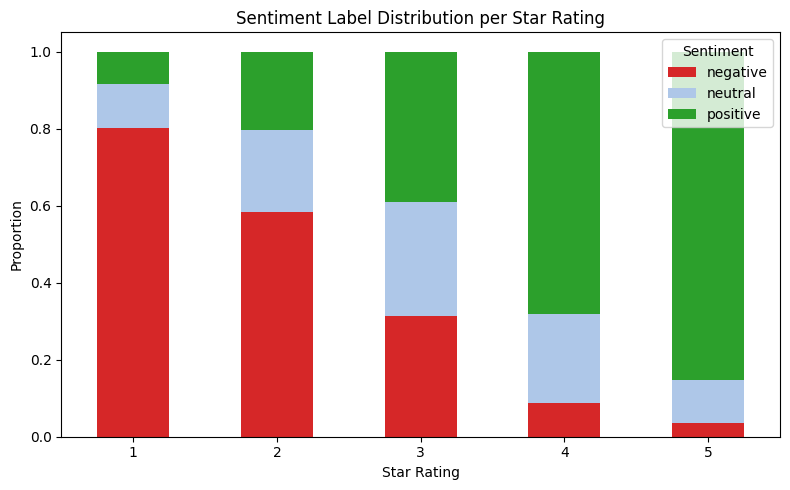

sentiment_label  negative  neutral  positive
rating                                      
1                   0.802    0.115     0.084
2                   0.584    0.213     0.203
3                   0.314    0.297     0.390
4                   0.088    0.230     0.682
5                   0.035    0.113     0.852


In [18]:
import matplotlib.pyplot as plt

# Proportion of each sentiment label per rating
alignment = (
    df_results.groupby(["rating", "sentiment_label"])
    .size()
    .reset_index(name="count")
)
alignment["proportion"] = alignment.groupby("rating")["count"].transform(lambda x: x / x.sum())

# Pivot for plotting
pivot = alignment.pivot(index="rating", columns="sentiment_label", values="proportion").fillna(0)

# Ensure consistent column order
for col in ["negative", "neutral", "positive"]:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[["negative", "neutral", "positive"]]

# Plot
pivot.plot(kind="bar", stacked=True, figsize=(8, 5),
           color=["#d62728", "#aec7e8", "#2ca02c"])
plt.title("Sentiment Label Distribution per Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

# Summary table
print(pivot.round(3))

## Step 3c — Confidence distribution Histogram of top-1 sentiment confidence

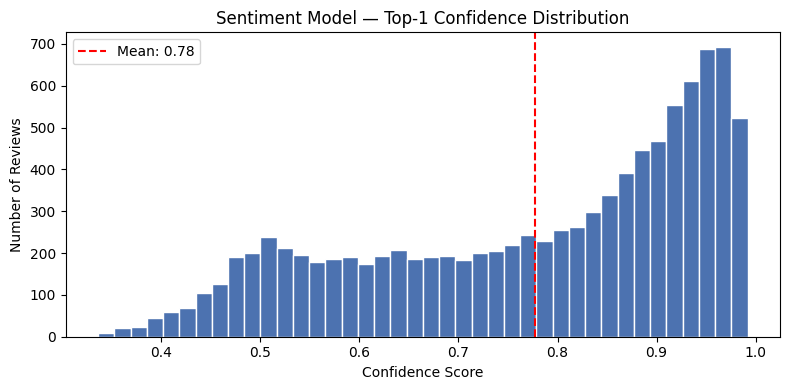

count    10000.000
mean         0.777
std          0.170
min          0.336
25%          0.638
50%          0.829
75%          0.927
max          0.992
Name: sentiment_confidence, dtype: float64


In [19]:
df_results["sentiment_confidence"] = df_results["sentiment_scores"].apply(
    lambda s: max(s.values())
)

plt.figure(figsize=(8, 4))
plt.hist(df_results["sentiment_confidence"], bins=40, color="#4c72b0", edgecolor="white")
plt.axvline(df_results["sentiment_confidence"].mean(), color="red", linestyle="--",
            label=f"Mean: {df_results['sentiment_confidence'].mean():.2f}")
plt.title("Sentiment Model — Top-1 Confidence Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Number of Reviews")
plt.legend()
plt.tight_layout()
plt.show()

print(df_results["sentiment_confidence"].describe().round(3))

### Confidence Analysis — Interpretation

The mean top-1 confidence is **0.78**, computed across all 10,000 reviews in this inference run.
This means the model assigns on average 78% probability to its predicted sentiment class.

For a 3-class classifier, random chance would yield a confidence of ~0.33.
A mean of 0.78 indicates the model is making decisive, non-trivial predictions on the majority of inputs.

- **75th percentile = 0.93** — most reviews are classified with very high confidence
- **Minimum = 0.336** — a small number of reviews sit near the decision boundary; these are
  genuinely ambiguous reviews (e.g. mixed language in a 3-star review) and low confidence here
  is the correct behaviour, not a model failure
- **Distribution shape** — right-skewed, with mass concentrated above 0.8, confirming the model
  is not hedging across classes

## Step 3d — Emotion label distribution Cell 18 — Emotion label counts

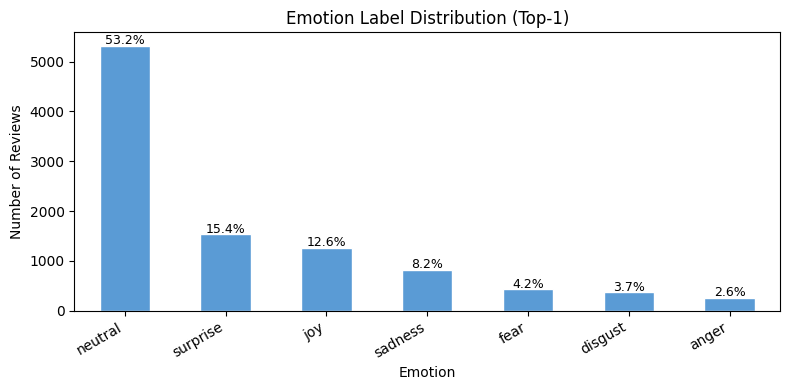

emotion_label
neutral     53.2
surprise    15.4
joy         12.6
sadness      8.2
fear         4.2
disgust      3.7
anger        2.6
Name: count, dtype: float64


In [20]:
emotion_counts = df_results["emotion_label"].value_counts()
emotion_pct = (emotion_counts / len(df_results) * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
emotion_counts.plot(kind="bar", ax=ax, color="#5a9bd5", edgecolor="white")
ax.set_title("Emotion Label Distribution (Top-1)")
ax.set_xlabel("Emotion")
ax.set_ylabel("Number of Reviews")
ax.set_xticklabels(emotion_counts.index, rotation=30, ha="right")
for i, (count, pct) in enumerate(zip(emotion_counts, emotion_pct)):
    ax.text(i, count + 30, f"{pct}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print(emotion_pct)

## Step 3e — Manual spot-checks Cell 19 — Sample reviews per emotion label

In [21]:
pd.set_option("display.max_colwidth", 200)

for emotion in ["joy", "anger", "surprise", "sadness", "neutral"]:
    print(f"\n{'='*60}")
    print(f"Emotion: {emotion.upper()}")
    print('='*60)
    sample = df_results[df_results["emotion_label"] == emotion][
        ["rating", "sentiment_label", "review_text"]
    ].sample(3, random_state=42)
    print(sample.to_string(index=False))


Emotion: JOY
 rating sentiment_label                                                                                                                                                                                                                                                                                                                                                                                                 review_text
      5        positive                                                                                                                                                                                                             The best one This is awesome , everything I was looking for , found everything I was looking for to . Easy to use perfect size to help be discreet , and a great price this is the one you want
      5        positive                                                                                                                           

### Spot-Check Interpretation — Manual Review of Emotion Labels

Three reviews per emotion label were sampled (random_state=42) and inspected manually.

---

**JOY — All 3 correctly labelled ✓**
All samples were rating 5 / positive sentiment with clearly enthusiastic language directed
at the product itself:
- "This is awesome, everything I was looking for"
- "Excited to see how it works"
- "I enjoy this product very much"
Emotion and sentiment are fully consistent. These are the clearest cases in the sample.

---

**ANGER — 1 of 3 correct, 2 identified as model limitations ⚠️**

- Rating 1 / negative: "Being charged for help is unacceptable. I'm sending the POS back."
  Anger is clearly directed at the product and company. Correct label. ✓

- Rating 5 / neutral: A laptop review containing an explicit "RANT" section directed entirely
  at competing brands (MSI, Asus, Intel), not at the reviewed product, which the reviewer
  praises enthusiastically. The model correctly detects angry tone in the text, but the anger
  is externally directed. Displaying "anger" as an emotion label here would be misleading from
  a UX perspective — a user might interpret it as dissatisfaction with the product itself. ⚠️

- Rating 1 / negative: A review arguing against purchasing Intel CPUs on market/pricing grounds
  ("Buying more of these processors is only entitling Intel to continue the outrageous price
  hike"). The anger is directed at a corporation's business practices rather than arising from
  a personal negative product experience. Structurally the same limitation as the case above —
  externally directed anger mislabelled as product-level emotion. ⚠️

  **Key limitation identified:** The model has no mechanism to distinguish anger directed at
  the reviewed product from anger directed at external entities (competitors, corporations,
  market practices) mentioned within the same text. This is the most significant failure mode
  found in this sample, and is relevant to UX deployment — externally directed anger on a
  high-rated review could confuse users.

---

**SURPRISE — All 3 correctly labelled ✓**
All samples were rating 5 / positive, with explicit surprise language tied to unexpectedly
good performance:
- "I don't know why so many people are having issues — it's freaking amazing"
  (surprised by contrast with negative reviews)
- "It installed games faster than the internal drive... ONE PERCENT [of storage used]"
  (surprised by storage performance)
- "I am impressed with the colors, wasn't really expecting the colors to be so good at
  such a low price point"
  (explicit expectation violation)
All three contain clear linguistic markers of surprise. ✓

---

**SADNESS — 1 correct, 1 borderline case ⚠️**

- Rating 1 / negative: "Stopped working after 8 weeks... replacement never came after
  3.5 months of emails." Disappointment and loss are the dominant tones — sadness is
  well-justified. ✓

- Rating 2 / neutral: A review of a UPS battery that opens positively ("I love the little
  LCD display") but criticises misleading battery life specifications. The label is sadness,
  but the tone reads closer to frustration or disgust at false advertising rather than genuine
  sadness. This is a borderline case where multiple labels are plausible; the correct label
  is debatable. ⚠️

---

**Overall assessment:**
The model performs well on clear, product-focused emotions (joy, surprise, straightforward anger
and sadness). The most significant and recurring failure mode is **externally directed emotion**:
reviews where the writer expresses strong emotion toward competitors, corporations, or market
conditions rather than toward the reviewed product. In 2 out of 3 anger samples, the anger was
externally directed, suggesting this may not be an isolated edge case.

**Implications for UX deployment:**
Displaying emotion labels derived from externally directed sentiment could mislead users.
A potential mitigation — beyond the scope of this prototype — would be to incorporate
aspect-level or target-aware sentiment analysis to identify who or what the emotion is directed at.

**Known model limitation:**
Both models were trained on Twitter and social media data, which is shorter and more expressive
than Amazon reviews. Long, structured reviews (detailed specs, comparisons, multi-section
arguments) may have their emotion label driven by a single rant section rather than the
overall review stance. The 512-token truncation limit also means that for very long reviews,
only the first ~380 words are evaluated — later sections, including conclusions, may be ignored.